# Exercise 1
Obtain the full book text parsed into words, a vocabulary, and encoder and decoder functions.
Include a second input into the encoder() and decoder() functions to provide the vocabular.


In [32]:
import numpy as np, requests, re

In [2]:
book = requests.get('https://gutenberg.org/cache/epub/35/pg35.txt')

text = book.text

# character strings to replace with space
string2replace = ['\r\n',
                '\r\n\r\nâ\x80\x9c',
    'â\x80\x9c',
    'â\x80\x9d',
    '\r\n',
    'â\x80\x94',
    'â\x80\x99',
    'â\x80\x98',
    '—',]

for i in string2replace:
    regexp = re.compile(rf'{i}')
    text = regexp.sub(' ', text)

# remove non-ASCII characters
text = re.sub(r'[^\x00-\x7F]+', ' ', text)

# remove numbers
text = re.sub('\d+','', text)

# make everything lowercase
text = text.lower()

# split by punctuation
import string

punctuationsForRegularExpression = f'[{string.punctuation}\s]+'

words = re.split(punctuationsForRegularExpression, text)
words = [item.strip() for item in words if item.strip()]    #stip() removes spaces

# remove single character words
words = [item for item in words if len(item)>1]

vocab = sorted(set(words))

nWords = len(words)
nLex = len(vocab)

print(f'no of words: {nWords}')
print(f'no of tokens: {nLex}')

wordToIndex = {w:i for i,w in enumerate(vocab)}
IndexToWord = {i:w for i,w in enumerate(vocab)}

def encoder(words, encode_dict):
    indexes = np.zeros(len(words),dtype=int)
    for i,w in enumerate(words):
        indexes[i] = encode_dict[w]
    return indexes

def decoder(indexes, decode_dict):
    return ' '.join([decode_dict[i] for i in indexes])

no of words: 33607
no of tokens: 4919


# Exercise 2 : Random walk through the time machine
Generate 10 random integers and create a sentence from those tokens

In [3]:
import random

randomTokens = [random.randint(1,len(vocab)) for _ in range(10)]

sentence = decoder(randomTokens, IndexToWord)
sentence

'hoax rapped author hugely feverish tumulus flowers easily sheep five'

Generate 30 random token IDs as Brownian noise starting from a randomly selected token ID

In [22]:
randomIndex = random.randint(1,len(vocab))
brownNoise = []
# brownNoise = np.cumsum(np.random.choice([-1,1],30))
print(randomIndex)
# print(randomChoice)
borwnarray = []
for i in range(30):
    randomChoice  = random.choice([1,-1])
    borwnarray.append(randomChoice)
    randomIndex += randomChoice
    brownNoise.append(randomIndex)

brownSentence = decoder(brownNoise, IndexToWord)
print(borwnarray)
print(brownSentence)

3060
[1, 1, -1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, 1, -1, -1, -1, 1, 1, 1, 1, 1, 1]
parapets parcels parapets parcels parent parcels parapets parapet paralyse parallel paralyse parapet parapets parcels parent parcels parapets parapet paralyse parallel paralyse parallel paragraphs paragraph paragraphs parallel paralyse parapet parapets parcels


## Exercise 3 : Distribution of word lengths
Count the number of characters in each word of the text.
Make a scatter plot and histogram

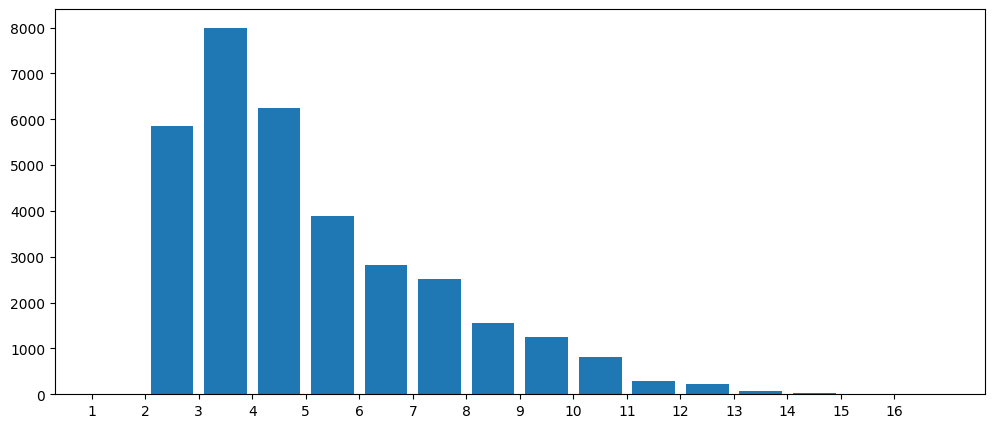

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
x: 33607
y: 16


In [35]:
import matplotlib.pyplot as plt
indexes = np.zeros(nWords, dtype=int)
for i in range(nWords):
    indexes[i] = len(words[i])

plt.figure(figsize=(12,5))
bins = range(1, max(indexes) + 2)
plt.hist(indexes,bins=bins, rwidth=0.8)
plt.xticks(range(1, max(indexes) + 1))

plt.show()
print(list(range(max(indexes))))
print(f'x: {len(indexes)}')
print(f"y: {len(list(range(1,max(indexes)+1)))}")



# Exercise 4 : Encode a novel sentence

In [46]:
sentence = 'The space aliens came to Earth to steal watermelons and staplers.'

words_new = re.sub(rf"[{re.escape(string.punctuation)}]","",sentence).lower().split()
words_new

['the',
 'space',
 'aliens',
 'came',
 'to',
 'earth',
 'to',
 'steal',
 'watermelons',
 'and',
 'staplers']

In [47]:
encodedWords = encoder(words_new, wordToIndex)
print(encodedWords)

KeyError: 'aliens'

# Exercise 5 : Create a new encoder
Tokens not in the vocab should be encoded using a special token for <|unk|>

In [ ]:
def encoder(words, encode_dict):
    indexes = np.zeros(len(words),dtype=int)
    for i,w in enumerate(words):
        try:
            indexes[i] = encode_dict[w]
        except:
            indexes['<|unk|>'] = w 
    return indexes


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices